## **Potholes Detection using Ultralytics YOLO26**

### **Mount Google Drive with the Google Colab Notebook**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd "/content/drive/MyDrive"

In [ ]:
!mkdir "Potholes_Detection"

In [ ]:
%cd "/content/drive/MyDrive/Potholes_Detection"

**Install the Ultralytics Package**

In [ ]:
!pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()

**Import All the Required Libraries**

In [ ]:
from IPython.display import Image

**Download Dataset from Roboflow**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="WZvSehAWhVgUvmLXafNx")
project = rf.workspace("muhammad-moin-qbwes").project("pothole-detection-v2ihv")
version = project.version(1)
dataset = version.download("yolo26")


**Train/ Fine-Tune the YOLO26 Model on Pothole Image Dataset**

In [ ]:
# Start training from a pretrained *.pt model
!yolo task=detect mode=train data="Pothole-Detection-1/data.yaml" model="yolo26n.pt" epochs=100 imgsz=640

**Examine the Training Results**

In [ ]:
!ls "runs/detect/train"

**F1-Confidence Curve**

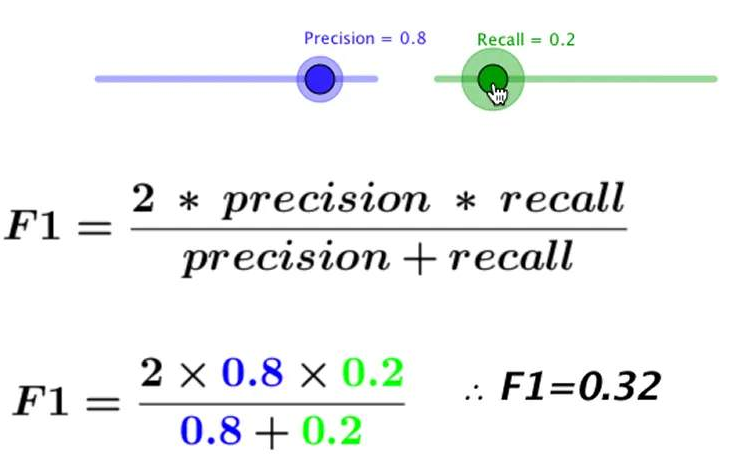

In [ ]:
Image("runs/detect/train/BoxF1_curve.png", width=600)

**Precision - Confidence Curve**

Precision = TP/(TP + FP)

Precision in Computer Vision is a Metric that tells you:

Out of all detections your model predicted as positive, how many were actually correct?

TP (True Positives) -> Correct Detections

FP (False Positive) -> Wrong Detection (Model predicted an object but it wasn't actually there)


A high Precision means:

*   Few false alarms
*   Most detected objects are correct
*   The model is reliable when it says “I found something”

A low Precision means:

*   Many false positives
*   Model keeps detecting objects where none exist

8 detections are correct (TP = 8)

2 detections are wrong (FP = 2)

In [ ]:
Image("runs/detect/train/BoxP_curve.png", width=600)

**Recall - Confidence Curve**

Recall measures how well your model finds all the relevant objects.


Recall tells you: Out of all the actual objects present, how many did the model detect?

Recall = TP / (TP + FN)


Where:

TP (True Positives) → Correct detections

FN (False Negatives) → Objects your model missed


Correctly detected 8 (TP = 8)

Missed 2 (FN = 2)

In [ ]:
Image("runs/detect/train/BoxR_curve.png", width=600)

**Precision - Recall Curve**

In [ ]:
Image("runs/detect/train/BoxPR_curve.png", width=600)

**Confusion Matrix**

In [ ]:
Image("runs/detect/train/confusion_matrix.png", width=600)

**Training and Validation Loss**

In [ ]:
Image("runs/detect/train/results.png", width=600)

**Model Prediction on the Validation Batch**

In [ ]:
Image("runs/detect/train/val_batch0_pred.jpg", width=600)

In [ ]:
Image("runs/detect/train/val_batch1_pred.jpg", width=600)

**Validating the Fine-Tuned Model**

In [ ]:
!yolo task=detect mode=val model="runs/detect/train/weights/best.pt" data="Pothole-Detection-1/data.yaml"

In [ ]:
!ls "runs/detect/val"

**Download the Model Weights from Drive**

In [ ]:
!gdown "https://drive.google.com/uc?id=180cpSeamfdbheJ8c19fficjj7cGOu1p4&confirm=t"

**Inference on Test Dataset Images**

In [ ]:
!yolo task=detect mode=predict model="best.pt" conf=0.25 source="Pothole-Detection-1/test/images" save=True

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('runs/detect/predict3/'), key=os.path.getmtime)

images = glob.glob(f'{latest_folder}/*.jpg')

selected_images = images[10:20] + images[30:40] + images[50:60]

for img in selected_images:
    display(IPyImage(filename=img, width=600))
    print("\n")


**Inference on Custom Video**

In [ ]:
!gdown "https://drive.google.com/uc?id=1iMitK9VCUWmBcZiiEPHK1d2pydALof6s&confirm=t"

In [ ]:
!yolo task=detect mode=predict model="best.pt" conf=0.25 source="demo.mp4" save=True

In [ ]:
!rm "/content/result_compressed.mp4"

In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = 'runs/detect/predict4/demo.avi'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)